In [66]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
from pandas import read_sql
from sqlite3 import connect
import seaborn as sns

In [67]:
# Create a static dashboard in a notebook using widgets to switch views, filters, or scenarios.
# • Include multiple visuals that highlight your key findings and support a narrative.
# • Keep visuals readable and well-labeled (titles, axes, units, captions when needed).
# • Include a short written summary in the dashboard that explains what the viewer should learn.

interactive(children=(IntSlider(value=50, description='y'), Output()), _dom_classes=('widget-interact',))

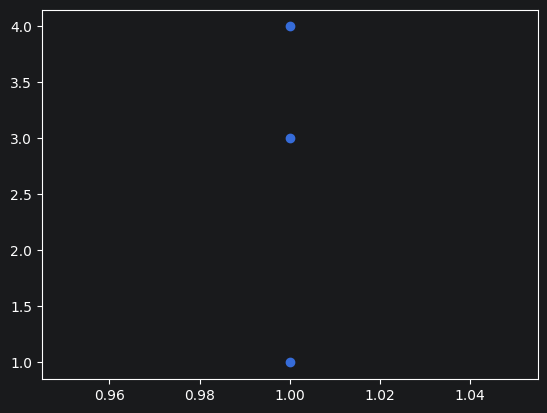

In [68]:
@widgets.interact(y=(0, 100, 1))
def display_widget(y):
    plt.scatter([1, 1, 1], [1, y, y + 1])

display_widget(3)

### Sentiment Distribution per Length

In [84]:
# Bar chart showing distribution of article length by sentiment
def chart_sentiment_dist_over_length(table_name, column, date_column, method="vader", threshold=500000):
    query = f"""SELECT {column}, IF(`{method} sentiment` > {threshold}, 'positive', 'negative') sentiment, strftime('%Y-%m', {date_column}) month_released
                FROM {table_name}
                WHERE month_released BETWEEN "2021-01" AND "2025-12"
                ORDER BY month_released, strftime('%m', {column});"""
    conn = connect("db.sqlite")

    df = read_sql(query, conn)
    df["length"] = df[column].apply(len)
    df = df[df["length"] < threshold]
    sns.boxplot(x="sentiment", y='length', data=df)
    plt.show()


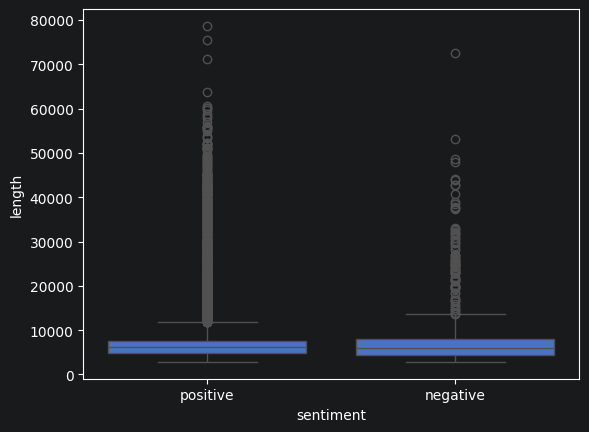

In [85]:
chart_sentiment_dist_over_length("Articles", "text", date_column="date")

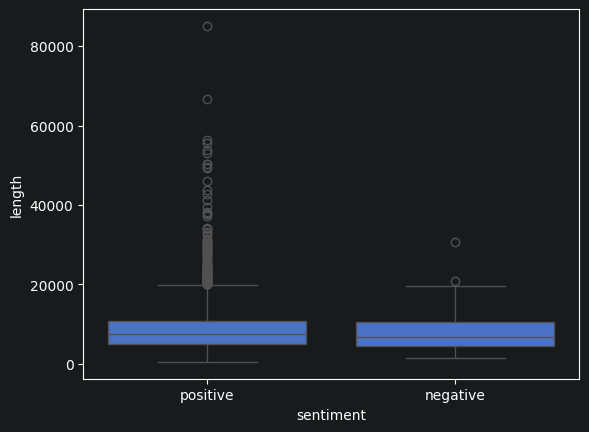

In [86]:
chart_sentiment_dist_over_length("DevPosts", "body_text", date_column="published_at")


### Sentiment Distribution per Topic

In [ ]:
# Interactive pie chart to show % of articles/posts that are positive or negative with tabs to switch between different topics

### Topic discussion over time

In [55]:
# Line chart with n lines per n topics popularity over time. Maybe have tabs per topic instead of lines on the same plot

### Sentiment changes over time

In [51]:
# Line chart with 2 lines, positive and negative sentiment over time
def chart_sentiment_change_over_months(table_name, column, method="vader", threshold=0):
    query = f"""SELECT strftime('%Y-%m', {column}) month_released,
    SUM(IF(`{method} sentiment` > {threshold}, 1, 0)) * 100 / count(*) positive,
    SUM(IF(`{method} sentiment` < -{threshold}, 1, 0)) * 100 / count(*) negative
                FROM {table_name}
                WHERE month_released BETWEEN "2021-01" AND "2025-12"
                GROUP BY month_released
                ORDER BY month_released, strftime('%m', {column});"""
    conn = connect("db.sqlite")

    df = read_sql(query, conn)
    plt.plot(df["negative"], label="Negative")
    plt.plot(df["positive"], label="Positive")
    plt.xlabel("Month")
    plt.ylabel("Sentiment %")
    plt.title("Sentiment Change over Months")
    df["month_released"] = df["month_released"].apply(lambda x: "" if int(x[-2:]) % 6 != 0 else x)
    plt.legend()
    plt.xticks(ticks=list(range(len(df))), labels=df["month_released"], rotation=90)
    plt.show()

    return df
#date, published_at

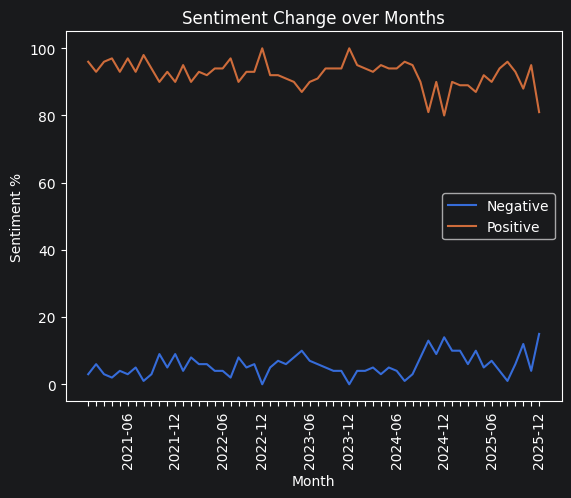

In [52]:
articles_df = chart_sentiment_change_over_months("Articles", "date")

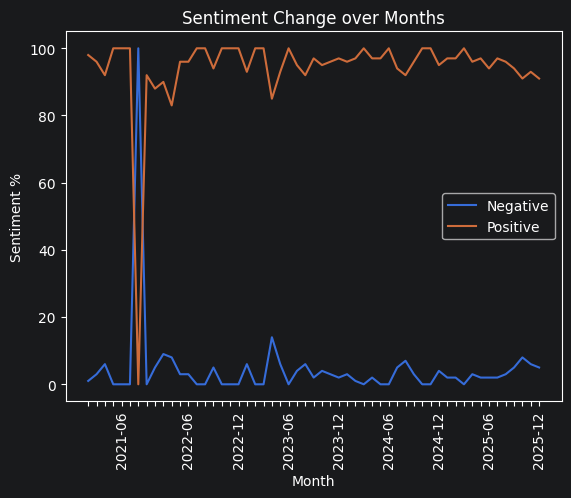

In [53]:
dp_df = chart_sentiment_change_over_months("DevPosts", "published_at")


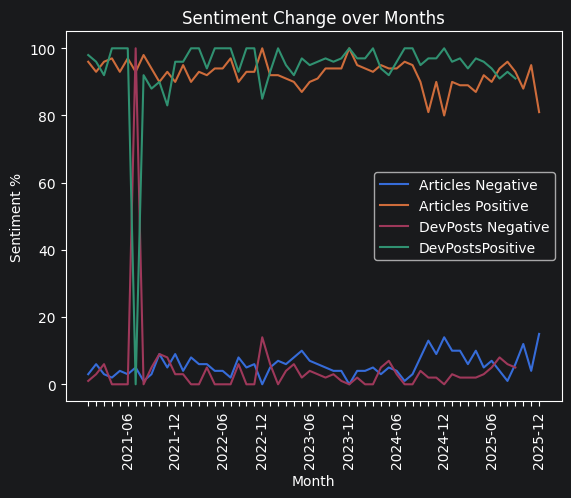

In [54]:
plt.plot(articles_df["negative"], label="Articles Negative")
plt.plot(articles_df["positive"], label="Articles Positive")

plt.plot(dp_df["negative"], label="DevPosts Negative")
plt.plot(dp_df["positive"], label="DevPostsPositive")
plt.xlabel("Month")
plt.ylabel("Sentiment %")
plt.title("Sentiment Change over Months")
plt.legend()
plt.xticks(ticks=list(range(len(articles_df))), labels=articles_df["month_released"], rotation=90)
plt.show()